In [2]:
from datetime import datetime
from time import sleep
import urllib.request
from bs4 import BeautifulSoup
import re
import pandas as pd

""" コース毎に各レースの人気グラフデータを取得する """
def RaceBirdsEye(rc_xxR):
    """ Scraping """
    race_url="https://race.netkeiba.com/?pid=race_old&id=c2019" + rc_xxR # rc.grc("阪神sat") + "12"

    cal_html = urllib.request.urlopen(race_url)
    print(cal_html.getcode(), end=" ")
    cal_soup = BeautifulSoup(cal_html,"lxml")
    cal_df = pd.io.html.read_html(cal_soup.prettify())
    entries_df = cal_df[0]
    entries_df.columns = entries_df.columns.droplevel() # 表示の項目名が２重になっているため

    """ レース情報の取得 """
    data_soup = cal_soup.find("dl", class_="racedata fc")
    other_soup = cal_soup.find("div", class_="race_otherdata")
    race_course = other_soup.find_all("p")[1].string
    race_course = re.sub("\d+回", "", race_course)[:2]
    race_no = re.sub("\n", "", data_soup.find("dt").string)
    race_name = re.sub("<[^>]*?>", "", str(data_soup.find("h1")))
    race_name = re.sub("\xa0", "", race_name)

    """ オッズ情報の取得 """
    odds_lst= []
    idx_lst = []
    for i, odds in enumerate(entries_df['単勝  オッズ']): # 予想  オッズ -> 単勝オッズ
        if(type(odds) != str):
            odds_lst.append(odds)
            idx_lst.append(i)
        elif('.' in odds):  # 取消が含まれていると全ての要素がstr型になる
            odds_lst.append(float(odds))
            idx_lst.append(i)
        else:
            print(Color.White + "{} 番: {} のため除外".format(i+1, odds) + Color.End)

    idx = idx_lst[(odds_lst.index(min(odds_lst)))]
    Most_Popularity = str(entries_df['馬  番'][idx]).rjust(2,"0") + " " + entries_df['馬名'][idx] \
                        + " " + entries_df['騎手'][idx] + " " + str(entries_df['単勝  オッズ'][idx])
    
    """ 返り値 （レース名、１番人気、支持率リスト） """
    Race_Title = race_course + " " + race_no + " " + race_name
    odds_lst.sort()
    Popularity_Rate = [round((0.8 / ods)*100, 2) for ods in odds_lst] # 単勝控除率0.8
    
    return Race_Title, Most_Popularity, Popularity_Rate

print("code loading ", datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

code loading  2019/10/06 00:39:32


In [3]:
# import importlib
# importlib.reload(mrc)
import myrace as mrc
from mycolor import *

rc = mrc.Rcd('新潟sun')
title_lst1 = []
rate_lst1 = []
most_lst1 = []
for i in range(1,13):
    rc_xxR = rc.grc() + str(i).rjust(2,"0")
    title, most, rate = RaceBirdsEye(rc_xxR)
    title_lst1.append(title)
    most_lst1.append(most)
    rate_lst1.append(rate)
print(datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

200 200 200 200 200 200 200 200 200 200 200 200 2019/10/06 00:40:09


In [4]:
rc = mrc.Rcd('京都sun')
title_lst2 = []
rate_lst2 = []
most_lst2 = []
for i in range(1,13):
    rc_xxR = rc.grc() + str(i).rjust(2,"0")
    title, most, rate = RaceBirdsEye(rc_xxR)
    title_lst2.append(title)
    most_lst2.append(most)
    rate_lst2.append(rate)
print(datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

200 200 200 200 200 200 200 200 200 200 200 200 2019/10/06 00:40:37


In [5]:
rc = mrc.Rcd('東京sun')
title_lst3 = []
rate_lst3 = []
most_lst3 = []
for i in range(1,13):
    rc_xxR = rc.grc() + str(i).rjust(2,"0")
    title, most, rate = RaceBirdsEye(rc_xxR)
    title_lst3.append(title)
    most_lst3.append(most)
    rate_lst3.append(rate)
print(datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

200 200 200 200 200 200 200 200 200 200 200 200 2019/10/06 00:41:02


2019/10/06 00:45:52


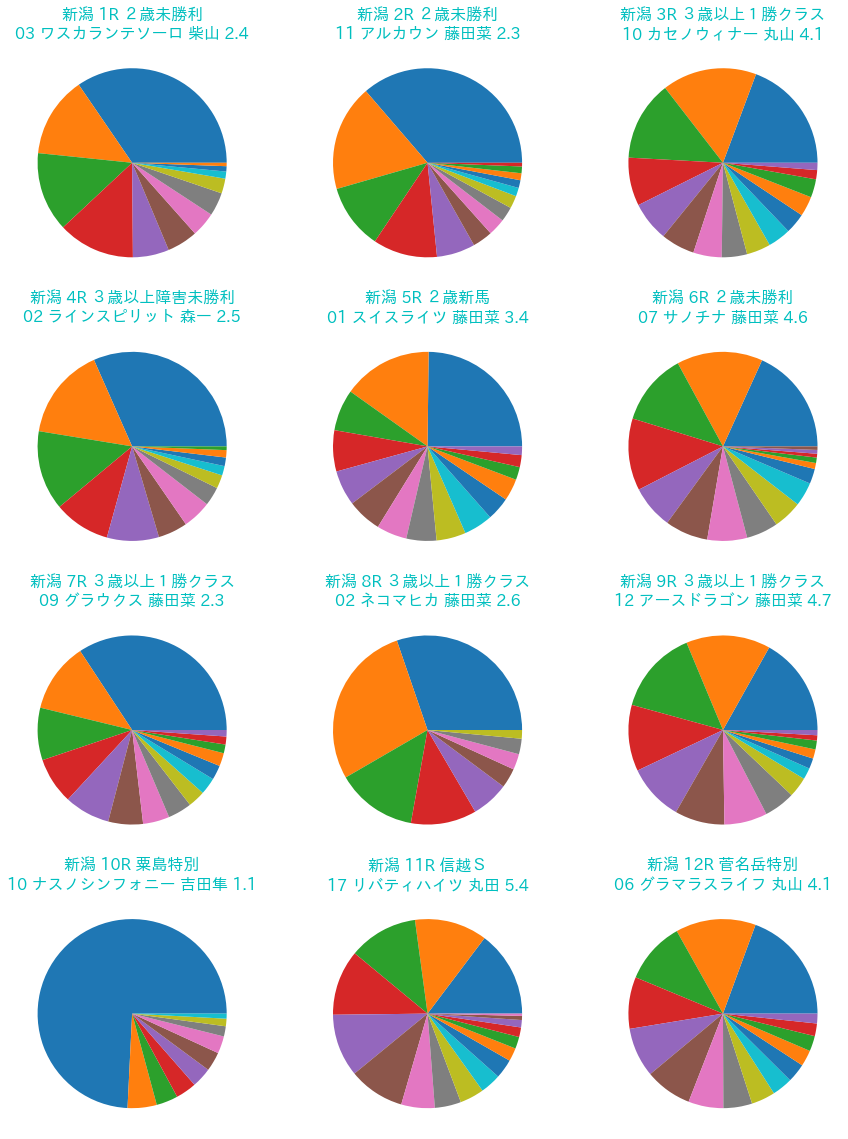

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams["font.family"] = "IPAexGothic"
plt.figure(figsize=(15, 20))

for i in range(1,13):
    plt.subplot(4,3,i)
    plt.title("{}\n{}".format(title_lst1[i-1], most_lst1[i-1]), fontsize=16, color="c")
    plt.pie(rate_lst1[i-1])
    
print(datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

2019/10/06 00:46:27


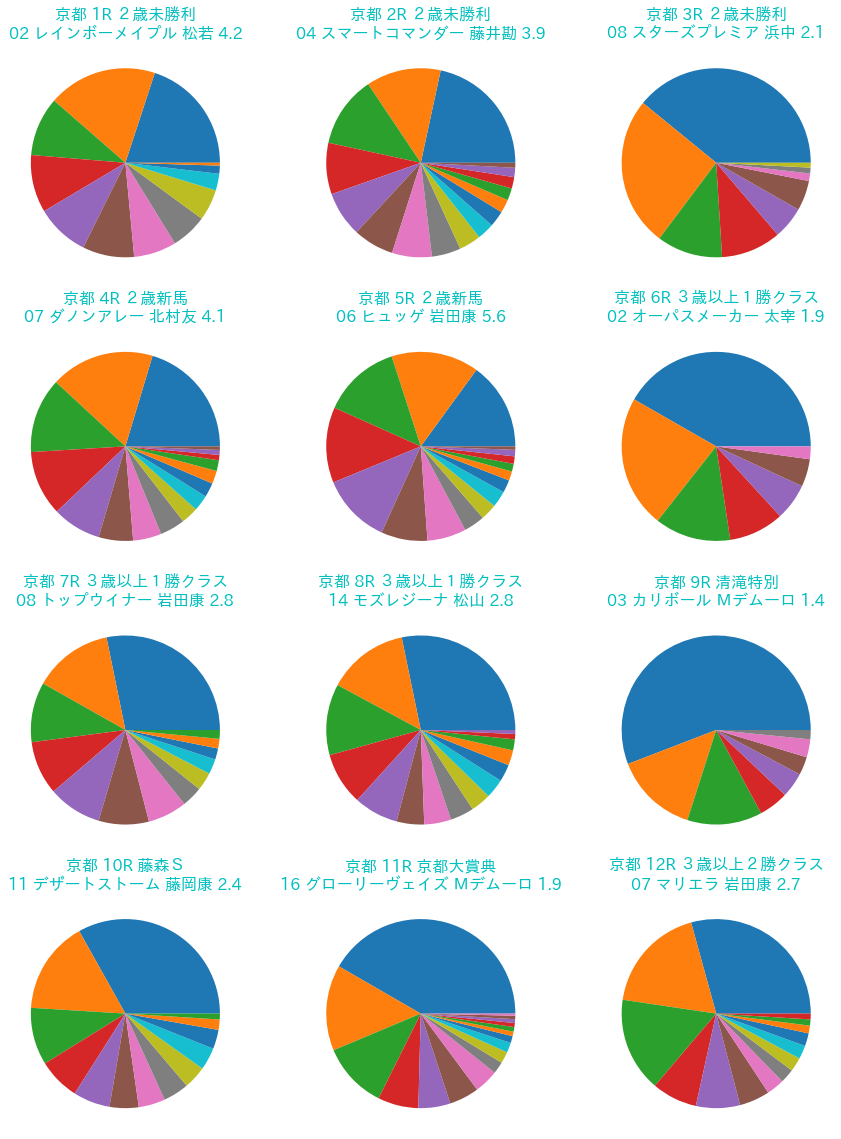

In [7]:
plt.figure(figsize=(15, 20))

for i in range(1,13):
    plt.subplot(4,3,i)
    plt.title("{}\n{}".format(title_lst2[i-1], most_lst2[i-1]), fontsize=16, color='c')
    plt.pie(rate_lst2[i-1])
    
print(datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

2019/10/06 00:47:44


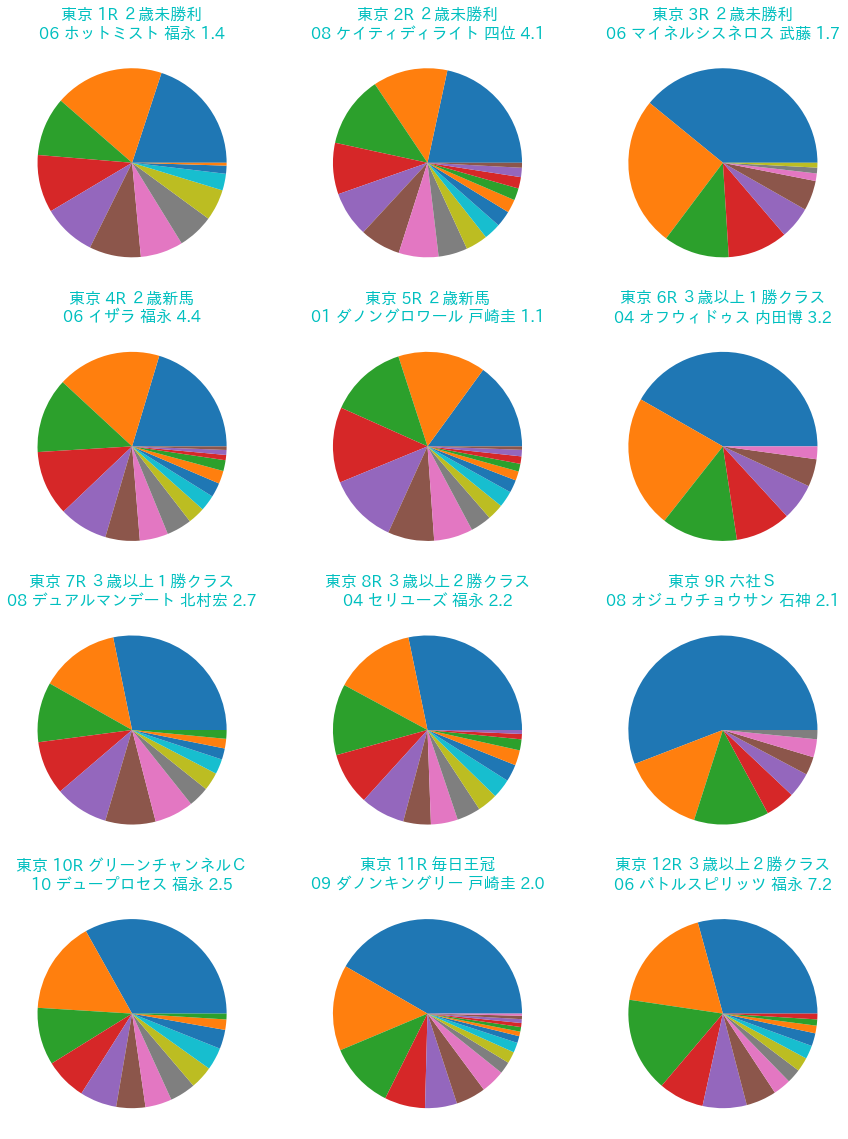

In [8]:
plt.figure(figsize=(15, 20))

for i in range(1,13):
    plt.subplot(4,3,i)
    plt.title("{}\n{}".format(title_lst3[i-1], most_lst3[i-1]), fontsize=16, color='c')
    plt.pie(rate_lst2[i-1])
    
print(datetime.now().strftime("%Y/%m/%d %H:%M:%S"))